In [19]:
import warnings
warnings.filterwarnings('ignore')

In [20]:
import pandas as pd

In [21]:
features = pd.read_csv("data/alt_acsincome_ca_features_85.csv")
features.head()

,AGEP,COW,SCHL,MAR,OCCP,POBP,RELP,WKHP,SEX,RAC1P
0,41.0,4.0,24.0,1.0,2555.0,6.0,1.0,60.0,2.0,1.0
1,77.0,7.0,22.0,1.0,4920.0,39.0,0.0,35.0,1.0,1.0
2,38.0,1.0,18.0,1.0,440.0,6.0,1.0,50.0,1.0,1.0
3,30.0,1.0,22.0,5.0,1555.0,6.0,2.0,80.0,1.0,6.0
4,36.0,1.0,16.0,1.0,4030.0,314.0,1.0,70.0,2.0,1.0


In [22]:
labels = pd.read_csv("data/alt_acsincome_ca_labels_85.csv")
labels.head()

,PINCP
0,True
1,True
2,False
3,True
4,False


In [23]:
dataset = pd.concat([features, labels], axis=1)
dataset.head()

,AGEP,COW,SCHL,MAR,OCCP,POBP,RELP,WKHP,SEX,RAC1P,PINCP
0,41.0,4.0,24.0,1.0,2555.0,6.0,1.0,60.0,2.0,1.0,True
1,77.0,7.0,22.0,1.0,4920.0,39.0,0.0,35.0,1.0,1.0,True
2,38.0,1.0,18.0,1.0,440.0,6.0,1.0,50.0,1.0,1.0,False
3,30.0,1.0,22.0,5.0,1555.0,6.0,2.0,80.0,1.0,6.0,True
4,36.0,1.0,16.0,1.0,4030.0,314.0,1.0,70.0,2.0,1.0,False


In [24]:
shape = dataset.shape

* AGEP: Age
* COW: Class of worker
* SCHL: Educational attainment
* MAR: Marital status
* OCCP: Occupation
* POBP: Place of Birth
* RELP: Relationship
* WKHP: Hours worked per week past 12 months
* SEX: Sex
* RAC1P: Recoded detailed race code
* PINCP: Total person's income

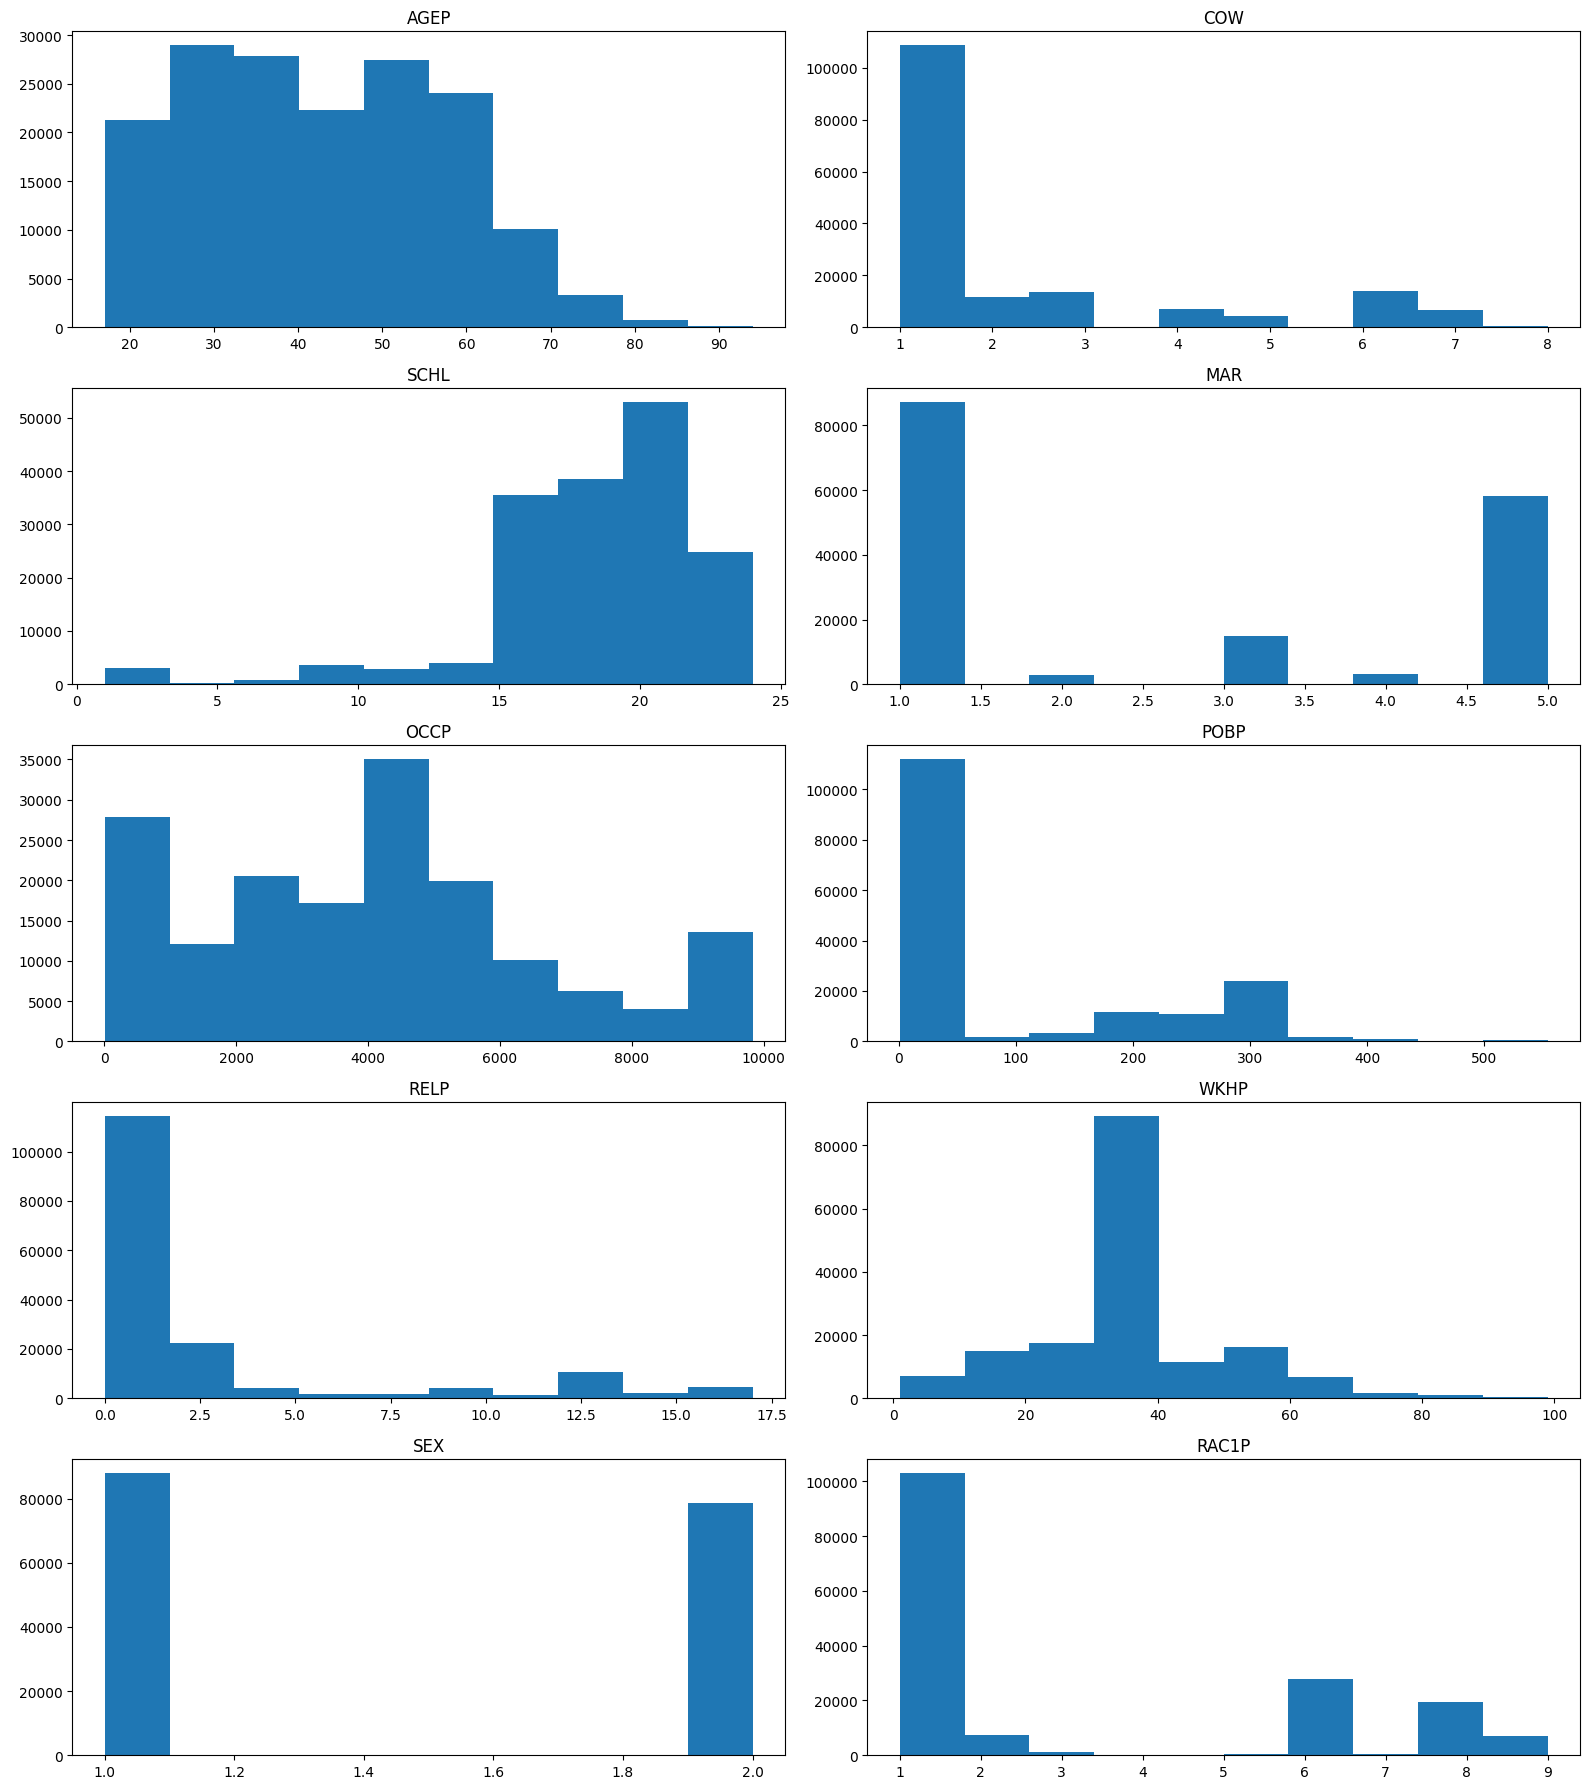

In [25]:
import matplotlib.pyplot as plt

num_cols = len(features.columns)
nrows = num_cols // 2 + num_cols % 2
ncols = 2

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 18))
axes = axes.flatten()

for i in range(num_cols):
    axes[i].hist(features.iloc[:, i])
    axes[i].set_title(features.columns[i])

for j in range(num_cols, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

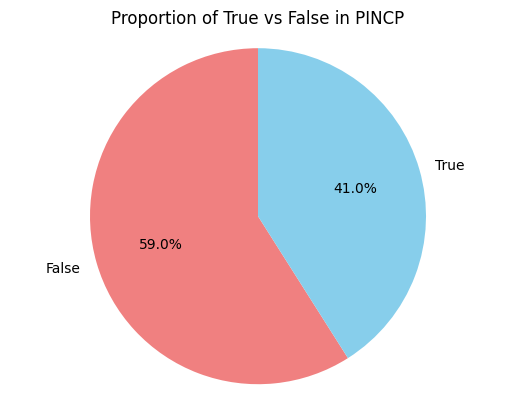

In [26]:
counts = labels['PINCP'].value_counts()

plt.pie(counts, labels=counts.index.astype(str), autopct='%1.1f%%', startangle=90, colors=['lightcoral', 'skyblue'])
plt.title('Proportion of True vs False in PINCP')
plt.axis('equal')

plt.show()

In [27]:
subdataset_of_trues = dataset[dataset["PINCP"] == True]
subdataset_of_trues.head()
subdataset_of_trues.shape

(68203, 11)

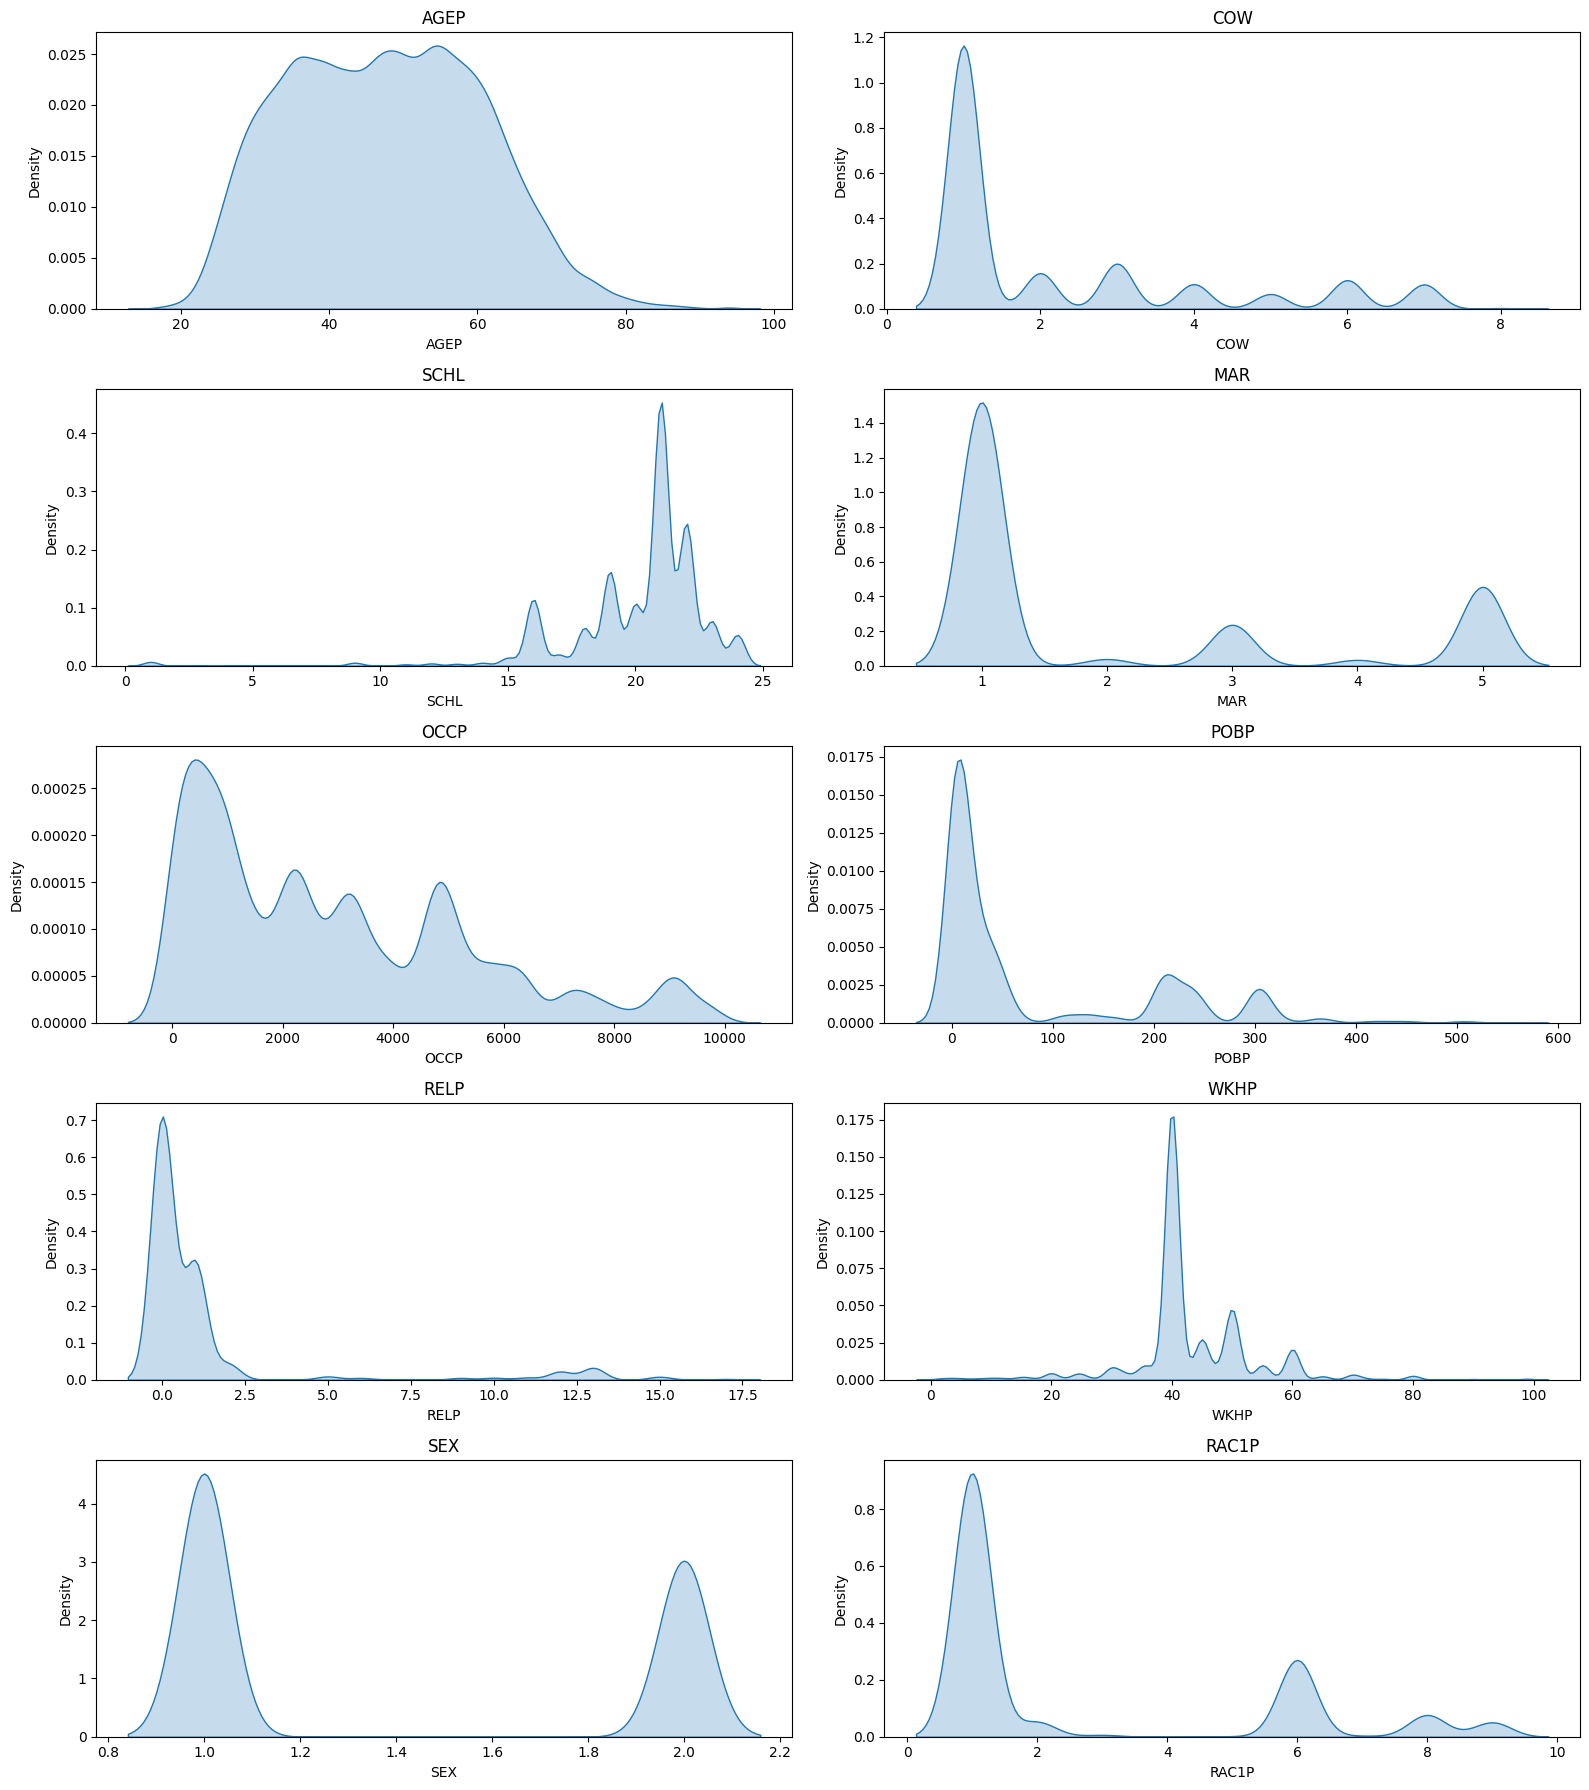

In [28]:
import seaborn as sns

subfeatures_of_trues = subdataset_of_trues.drop(columns=["PINCP"])
num_cols = len(subfeatures_of_trues.columns)
nrows = num_cols // 2 + num_cols % 2
ncols = 2

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 18))
axes = axes.flatten()

for i in range(num_cols):
    sns.kdeplot(subfeatures_of_trues.iloc[:, i], ax=axes[i], shade=True)
    axes[i].set_title(subfeatures_of_trues.columns[i])

for j in range(num_cols, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

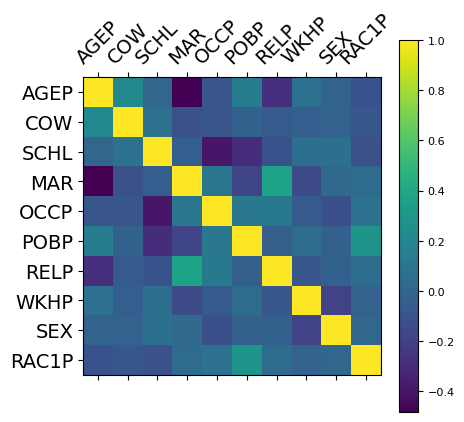

In [29]:
plt.matshow(features.corr())
plt.xticks(range(features.select_dtypes(['number']).shape[1]), features.select_dtypes(['number']).columns, fontsize=14, rotation=45)
plt.yticks(range(features.select_dtypes(['number']).shape[1]), features.select_dtypes(['number']).columns, fontsize=14)
cb = plt.colorbar()
cb.ax.tick_params(labelsize=8)
plt.show()

In [30]:
from sklearn.preprocessing import OneHotEncoder

columns_to_encode = ["COW", "SCHL", "MAR", "OCCP", "POBP", "RELP", "SEX", "RAC1P"]

encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
features_to_encode = features[columns_to_encode]

encoded_features_array = encoder.fit_transform(features_to_encode)
encoded_features_columns = encoder.get_feature_names_out(columns_to_encode)
encoded_features = pd.DataFrame(encoded_features_array, columns=encoded_features_columns, index=features.index)

features_remaining = features.drop(columns=columns_to_encode)
features_encoded = pd.concat([features_remaining, encoded_features], axis=1)
features_encoded.head()

,AGEP,WKHP,COW_1.0,COW_2.0,COW_3.0,COW_4.0,COW_5.0,COW_6.0,COW_7.0,COW_8.0,...,SEX_2.0,RAC1P_1.0,RAC1P_2.0,RAC1P_3.0,RAC1P_4.0,RAC1P_5.0,RAC1P_6.0,RAC1P_7.0,RAC1P_8.0,RAC1P_9.0
0,41.0,60.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,77.0,35.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,38.0,50.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,30.0,80.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,36.0,70.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [31]:
from sklearn.model_selection import train_test_split

features_train, features_test, labels_train, labels_test = train_test_split(features_encoded, labels, test_size=0.3, train_size=0.7)
print(features_train.shape)
print(features_test.shape)
print(labels_train.shape)
print(labels_test.shape)

(116420, 816)
(49895, 816)
(116420, 1)
(49895, 1)


## 2. Random Forest

### 2.1 Qualité d'apprentissage avec le paramétrage par défaut (Expe 1)

| Expérimentation 1     | Train   | Test   |
|-----------------------|---------|--------|
| Taille Jeu de Données | 116420  | 49895  |


In [32]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_validate
from sklearn.metrics import confusion_matrix, accuracy_score
"""
random_forest = RandomForestClassifier()
ada_boost = AdaBoostClassifier()
xg_boost = GradientBoostingClassifier()

for model in [random_forest, ada_boost, xg_boost]:
    print(model)
    validation_result = cross_validate(model, features_train, labels_train)
    
    print("Cross-validation Fit Times:", np.mean(validation_result["fit_time"]))
    
    model.fit(features_train, labels_train)
    
    train_prediction = model.predict(features_train)
    train_accuracy = accuracy_score(labels_train, train_prediction)
    train_confusion_matrix = confusion_matrix(labels_train, train_prediction)
    
    print("Training Accuracy:", train_accuracy)
    print("Training Confusion Matrix:\n", train_confusion_matrix)
    
    test_prediction = model.predict(features_test)
    test_accuracy = accuracy_score(labels_test, test_prediction)
    test_confusion_matrix = confusion_matrix(labels_test, test_prediction)

    print("Test Accuracy:", test_accuracy)
    print("Test Confusion Matrix:\n", test_confusion_matrix)

    print("=======================")
"""

'\nrandom_forest = RandomForestClassifier()\nada_boost = AdaBoostClassifier()\nxg_boost = GradientBoostingClassifier()\n\nfor model in [random_forest, ada_boost, xg_boost]:\n    print(model)\n    validation_result = cross_validate(model, features_train, labels_train)\n\n    print("Cross-validation Fit Times:", np.mean(validation_result["fit_time"]))\n\n    model.fit(features_train, labels_train)\n\n    train_prediction = model.predict(features_train)\n    train_accuracy = accuracy_score(labels_train, train_prediction)\n    train_confusion_matrix = confusion_matrix(labels_train, train_prediction)\n\n    print("Training Accuracy:", train_accuracy)\n    print("Training Confusion Matrix:\n", train_confusion_matrix)\n\n    test_prediction = model.predict(features_test)\n    test_accuracy = accuracy_score(labels_test, test_prediction)\n    test_confusion_matrix = confusion_matrix(labels_test, test_prediction)\n\n    print("Test Accuracy:", test_accuracy)\n    print("Test Confusion Matrix:\n"

| Résultats en entraînement <br/> (hyper-param par défaut) | Random Forest   | AdaBoost   | XGBoost |
|----------------------------------------------------------|-----------------|------------|---------|
| accuracy                                                 |       0.998     |     0.779  |  0.803  |
| temps de calcul (sec.)                                   |       47.4      |     16.2   |   58.9  |
| matrice de confusion                                     |       [68543&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;109]<br/>[90&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;47678]          |   [57064&nbsp;&nbsp;11588]<br/>[14189&nbsp;&nbsp;33579]         |   [58161&nbsp;&nbsp;10491]<br/>[12446&nbsp;&nbsp;35322]      |

<hr />

| Résultats en test <br/> (hyper-param par défaut) | Random Forest   | AdaBoost   | XGBoost |
|--------------------------------------------------|-----------------|------------|---------|
| accuracy                                         |     0.811       |    0.778   |   0.801 |
| matrice de confusion                             |     [25159&nbsp;&nbsp;4301]<br/>[5152&nbsp;&nbsp;15283]            |  [24469&nbsp;&nbsp;4991]<br/>[6070&nbsp;&nbsp;14365]          |   [24943&nbsp;&nbsp;4517]<br/>[5395&nbsp;&nbsp;15040]      |

### 2.2 Optimisation des hyperparamètres des modèles (Expe 2) 

| Expérimentation 1     | Train   | Test   |
|-----------------------|---------|--------|
| Taille Jeu de Données | 116420  | 49895  |


#### 1. Liste des hyperparamètres

##### a) Random Forest

- **n_estimators**: 100, 300, 500
- **max_depth**: None, 10, 20
- **min_samples_split**: 2, 5
- **max_features**: sqrt, log2

##### b) AdaBoost

- **n_estimators**: 50, 100, 200
- **learning_rate**: 0.5, 1.0
- **estimator.max_depth**: 1, 2

##### c) XGBoost

- **n_estimators**: 200, 500
- **max_depth**: 3, 6
- **learning_rate**: 0.05, 0.1
- **sub_sample**: 0.8, 1.0
- **loss**: log_loss, exponential

#### 2. Nombre de plis dans la validation croisée

On garde la valeur par défaut de Scikit-Learn: **5 plis**

#### 3. Estimation du nombre d'entraînements

Nombre d'entraînements par pli:

* **Random Forest**: 3 * 3 * 2 * 2 = **36**
* **AdaBoost**: 3 * 2 * 2 = **12**
* **XGBoost**: 2 * 2 * 2 * 2 * 2 = **32**

Vu qu'il y a 5 plis, le nombre total d'entraînements sera donc: 5 * 36 + 5 * 12 * 5 * 32 = **400 entraînements**


In [33]:
import time
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

"""
items = [
    (
        RandomForestClassifier, 
        {
            "n_estimators": [100, 300, 500],
            "max_depth": [None, 10, 20],
            "min_samples_split": [2, 5],
            "max_features": ["sqrt", "log2"],
        }
    ),
    (
        AdaBoostClassifier,
        {
            "n_estimators": [50, 100, 200],
            "learning_rate": [0.5, 1.0],
            "estimator": [
                DecisionTreeClassifier(max_depth=2),
                DecisionTreeClassifier(max_depth=3)
            ]
        }
    ),
    (
        GradientBoostingClassifier,
        {
            "n_estimators": [200, 500],
            "max_depth": [3, 6],
            "learning_rate": [0.05, 0.1],
            "subsample": [0.8, 1.0],
            "loss": ["log_loss", "exponential"],
        }
    ),
]


for ModelClass, params in items:
    model = ModelClass()
    
    grid = GridSearchCV(
        estimator=model,
        param_grid=params,
        cv=5,
        scoring="accuracy",
        n_jobs=-1,
        verbose=2
    )

    start = time.time()
    grid.fit(features_train, labels_train)
    end = time.time()
    
    print(f"===== {ModelClass} =====")
    print("Best params:", grid.best_params_)
    print("Best score:", grid.best_score_)
    print("Time:", end - start)
    
    labels_pred = grid.predict(features_test)
    print("Accuracy:", accuracy_score(labels_test, labels_pred))
    print(confusion_matrix(labels_test, labels_pred))
"""

'\nitems = [\n    (\n        RandomForestClassifier, \n        {\n            "n_estimators": [100, 300, 500],\n            "max_depth": [None, 10, 20],\n            "min_samples_split": [2, 5],\n            "max_features": ["sqrt", "log2"],\n        }\n    ),\n    (\n        AdaBoostClassifier,\n        {\n            "n_estimators": [50, 100, 200],\n            "learning_rate": [0.5, 1.0],\n            "estimator": [\n                DecisionTreeClassifier(max_depth=2),\n                DecisionTreeClassifier(max_depth=3)\n            ]\n        }\n    ),\n    (\n        GradientBoostingClassifier,\n        {\n            "n_estimators": [200, 500],\n            "max_depth": [3, 6],\n            "learning_rate": [0.05, 0.1],\n            "subsample": [0.8, 1.0],\n            "loss": ["log_loss", "exponential"],\n        }\n    ),\n]\n\n\nfor ModelClass, params in items:\n    model = ModelClass()\n\n    grid = GridSearchCV(\n        estimator=model,\n        param_grid=params,\n      

|                               | Train Accuracy | CPU Time | Test Accuracy  | Hyperparamètres  |
|-------------------------------|----------------|----------|----------------|------------------|
| Random Forest (par défaut)    | 0.998          | 47.4s    | 0.811          | defaults sklearn |
| Random Forest (optimisé)      | 0.819          | 30min    | 0.818          | max_depth: None<br/>max_features: "log2"<br/> min_samples_split: 5<br/> n_estimators: 300              |



|                           | Train Accuracy | CPU Time | Test Accuracy  | Hyperparamètres  |
|---------------------------|----------------|----------|----------------|------------------|
| AdaBoost (par défaut)     | 0.779          | 16.2     | 0.778          | defaults sklearn |
| AdaBoost (optimisé)       | 0.804          | 20min    | 0.805          | estimator: DecisionTreeClassifier(max_depth=3)<br/> learning_rate: 1.0<br/> n_estimators: 200             |


|                           | Train Accuracy | CPU Time | Test Accuracy  | Hyperparamètres  |
|---------------------------|----------------|----------|----------------|------------------|
| XGBoost (par défaut)      | 0.803          | 58.9     | 0.801          | defaults         |
| XGBoost (optimisé)        | 0.825          | 34min    | 0.823          | learning_rate: 0.1<br/> loss: "exponential"<br/> max_depth: 6<br/> n_estimators: 500<br/> subsample: 0.8              |

### 2.3 Analyse des résultats (Expe 3)

| Résultats en entraînement <br/> (hyper-param optimisés)  | Random Forest   | AdaBoost   | XGBoost |
|----------------------------------------------------------|-----------------|------------|---------|
| accuracy                                                 |       0.819     |     0.804  |  0.825  |
| temps de calcul (sec.)                                   |       10s       |     20s    |   13s   |

| Résultats en test <br/> (hyper-param optimisés)  | Random Forest   | AdaBoost   | XGBoost |
|--------------------------------------------------|-----------------|------------|---------|
| accuracy                                         |     0.818       |    0.805   |   0.823 |
| matrice de confusion                             |     [25284&nbsp;&nbsp;3992]<br/>[5080&nbsp;&nbsp;15539]            |  [24535&nbsp;&nbsp;4741]<br/>[4970&nbsp;&nbsp;15649]          |   [25080&nbsp;&nbsp;4321]<br/>[4495&nbsp;&nbsp;15999]      |

### 2.4 Inférence sur un autre jeu de données (Expe 4)

In [34]:
from xgboost import XGBClassifier

best_random_forest = RandomForestClassifier(max_depth=None, max_features="log2", min_samples_split=5, n_estimators=300, n_jobs=-1)
best_ada_boost = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3), learning_rate=1.0, n_estimators=200)
best_xg_boost = XGBClassifier(learning_rate=0.1, loss="exponential", max_depth=6, n_estimators=500, subsample=0.8, tree_method="hist", device="cuda", n_jobs=1)

"""
for model in [best_random_forest, best_ada_boost, best_xg_boost]:
    print(model)
    model.fit(features_train, labels_train)
"""

'\nfor model in [best_random_forest, best_ada_boost, best_xg_boost]:\n    print(model)\n    model.fit(features_train, labels_train)\n'

In [35]:
for state in ["co", "ne"]:
    print(f"Results for State {state.upper()} ==============================================================")
    
    state_features = pd.read_csv(f"data/acsincome_{state}_allfeatures.csv")
    print(state_features.head())
    
    state_labels = pd.read_csv(f"data/acsincome_{state}_label.csv")
    print(state_labels.head())

    encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
    state_features_to_encode = state_features[columns_to_encode]

    encoded_state_features_array = encoder.fit_transform(state_features_to_encode)
    encoded_state_features_columns = encoder.get_feature_names_out(columns_to_encode)
    encoded_state_features = pd.DataFrame(encoded_state_features_array, columns=encoded_state_features_columns, index=state_features.index)
    
    state_features_remaining = state_features.drop(columns=columns_to_encode)
    state_features_encoded = pd.concat([state_features_remaining, encoded_state_features], axis=1)
 
    # Add missing columns with value 0
    state_features_encoded = state_features_encoded.reindex(
        columns=features_encoded.columns,
        fill_value=0.0
    )
    
    print(state_features_encoded.head())

    for model in [best_random_forest, best_ada_boost, best_xg_boost]:
        print(model)
        
        state_prediction = model.predict(state_features_encoded)
        state_accuracy = accuracy_score(state_labels, state_prediction)
        state_confusion_matrix = confusion_matrix(state_labels, state_prediction)
    
        print("Accuracy:", state_accuracy)
        print("Confusion Matrix:\n", state_confusion_matrix)
    
        print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")

Results for State CO ==============================================================
   AGEP  COW  SCHL  MAR    OCCP  POBP  RELP  WKHP  SEX  RAC1P
0  19.0  2.0  19.0  5.0  2850.0   6.0  17.0   2.0  2.0    9.0
1  24.0  5.0  18.0  5.0  9645.0  13.0  17.0  40.0  1.0    2.0
2  22.0  1.0  19.0  5.0  1520.0  53.0  17.0  45.0  2.0    1.0
3  32.0  1.0  16.0  1.0  4055.0   8.0  16.0  40.0  2.0    1.0
4  19.0  2.0  19.0  5.0  2006.0  34.0  17.0   9.0  2.0    1.0
   PINCP
0      0
1      0
2      0
3      0
4      0
   AGEP  WKHP  COW_1.0  COW_2.0  COW_3.0  COW_4.0  COW_5.0  COW_6.0  COW_7.0  \
0  19.0   2.0      0.0      1.0      0.0      0.0      0.0      0.0      0.0   
1  24.0  40.0      0.0      0.0      0.0      0.0      1.0      0.0      0.0   
2  22.0  45.0      1.0      0.0      0.0      0.0      0.0      0.0      0.0   
3  32.0  40.0      1.0      0.0      0.0      0.0      0.0      0.0      0.0   
4  19.0   9.0      0.0      1.0      0.0      0.0      0.0      0.0      0.0   

   COW_8.

NotFittedError: This RandomForestClassifier instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

Les résultats obtenus sur les états de Nevada et Colorado se situent entre 0,73 et 0,79 d'accuracy : 

|  Etat / Accuracy            | Random Forest   | AdaBoost   | XGBoost |
|-----------------------------|-----------------|------------|---------|
| Californie (entraînement)   |       0.818     |     0.805  |  0.823  |
| Colorado                    |       0.782     |     0.768  |  0.787  |
| Nevada                      |       0.751     |     0.728  |  0.748  |

Ceci est certainement dû au fait qu'en fonction des états, les niveaux de vie diffèrent, de même que les paramètres qui influent sur eux. Un modèle entrainé sur un état X peut donc ne pas performer sur un état Y.

### 2.5 Impact de la taille du jeu de données (Expe 5)

In [18]:
for train_size in [0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2]:
    print(f"Results for train_size={train_size} ==============================")
    
    features_train, features_test, labels_train, labels_test = train_test_split(
        features_encoded, 
        labels, 
        test_size=1-train_size, 
        train_size=train_size
    )
    
    for model in [best_random_forest, best_ada_boost, best_xg_boost]:
        model_name = type(model).__name__
        print(f"Processing: {model_name}")
        
        validation_result = cross_validate(
            model, 
            features_train, 
            labels_train, 
            n_jobs=-1 if "AdaBoost" in model_name else 1
        )
        
        print("Cross-validation Fit Times:", np.mean(validation_result["fit_time"]))
        
        model.fit(features_train, labels_train)
        
        train_prediction = model.predict(features_train)
        train_accuracy = accuracy_score(labels_train, train_prediction)
        train_confusion_matrix = confusion_matrix(labels_train, train_prediction)
        
        print("Training Accuracy:", train_accuracy)
        print("Training Confusion Matrix:\n", train_confusion_matrix)
        
        test_prediction = model.predict(features_test)
        test_accuracy = accuracy_score(labels_test, test_prediction)
        test_confusion_matrix = confusion_matrix(labels_test, test_prediction)
    
        print("Test Accuracy:", test_accuracy)
        print("Test Confusion Matrix:\n", test_confusion_matrix)
    
        print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")

Results for train_size=0.6 ==============================
Processing: RandomForestClassifier
Cross-validation Fit Times: 4.675135755538941
Training Accuracy: 0.9696559741053623
Training Confusion Matrix:
 [[57585  1338]
 [ 1690 39176]]
Test Accuracy: 0.8176352102937198
Test Confusion Matrix:
 [[33734  5455]
 [ 6677 20660]]
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Processing: AdaBoostClassifier
Cross-validation Fit Times: 107.77312436103821
Training Accuracy: 0.8049985469340308
Training Confusion Matrix:
 [[49621  9302]
 [10157 30709]]
Test Accuracy: 0.8026636202387036
Test Confusion Matrix:
 [[32984  6205]
 [ 6923 20414]]
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Processing: XGBClassifier
Cross-validation Fit Times: 6.847369575500489
Training Accuracy: 0.8418262533946628
Training Confusion Matrix:
 [[50985  7938]
 [ 7846 33020]]
Test Accuracy: 0.8248955295673872
Test Confusion Matrix:
 [[33386  5803]
 [ 5846 21491]]
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Results for train_size=0.4 ===

## 3. Explicabilité des prédictions


Pour la suite, nous choisissons le modèle Random Forest.

In [36]:
model = best_xg_boost
model.fit(features_train, labels_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,'cuda'
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


### 3.1 Classement des attributs dans la prédiction

In [22]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    model,
    features_test,
    labels_test,
    n_repeats=10,
    random_state=42,
    n_jobs=4
)

importances = result.importances_mean
std = result.importances_std
features = features_test.columns

indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 6))
plt.bar(range(len(features)), importances[indices])
plt.xticks(range(len(features)), features[indices], rotation=90)
plt.title("Permutation Feature Importance")
plt.tight_layout()
plt.show()

KeyboardInterrupt: 

### 3.2 Explications locales

#### Examples choisis (commun aux deux méthodes)

In [40]:
samples_indices = np.random.choice(features_test.shape[0], size=3)
features_test.iloc[samples_indices]

,AGEP,WKHP,COW_1.0,COW_2.0,COW_3.0,COW_4.0,COW_5.0,COW_6.0,COW_7.0,COW_8.0,...,SEX_2.0,RAC1P_1.0,RAC1P_2.0,RAC1P_3.0,RAC1P_4.0,RAC1P_5.0,RAC1P_6.0,RAC1P_7.0,RAC1P_8.0,RAC1P_9.0
46822,24.0,40.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
75534,45.0,42.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
28177,42.0,40.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


#### 1. Méthode LIME

In [47]:
from lime.lime_tabular import LimeTabularExplainer
from IPython.display import HTML, display

lime_explainer = LimeTabularExplainer(
    training_data=np.array(features_train),
    feature_names=features_train.columns,
    class_names=["<=50k", ">50k"],
    mode="classification"
)

for i in samples_indices:
    explaination = lime_explainer.explain_instance(
        features_test.iloc[i].values,
        model.predict_proba
    )
    display(HTML(explaination.as_html()))

#### 2. Méthode SHAP

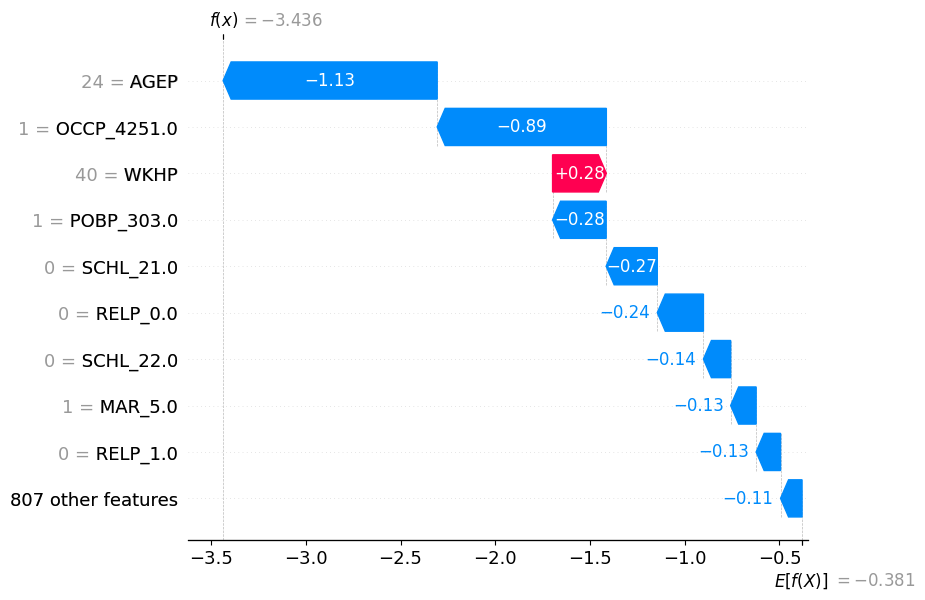

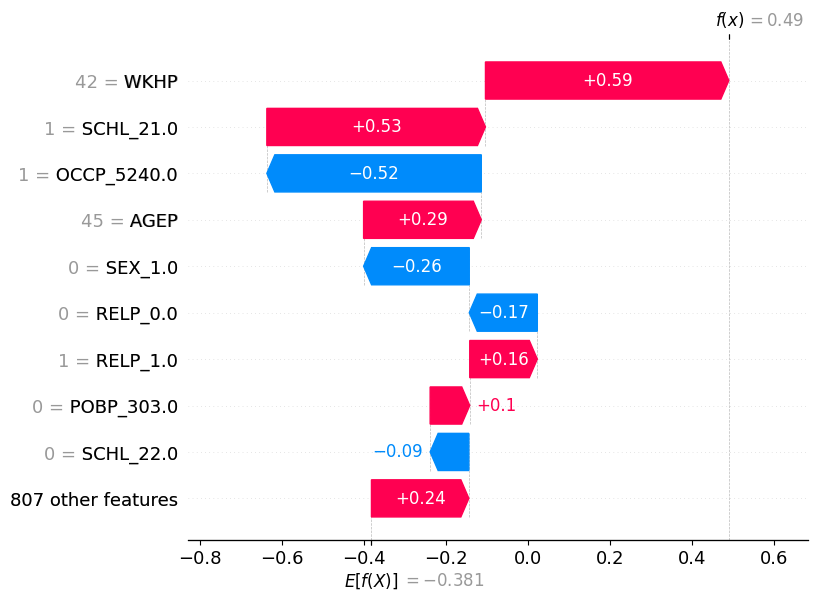

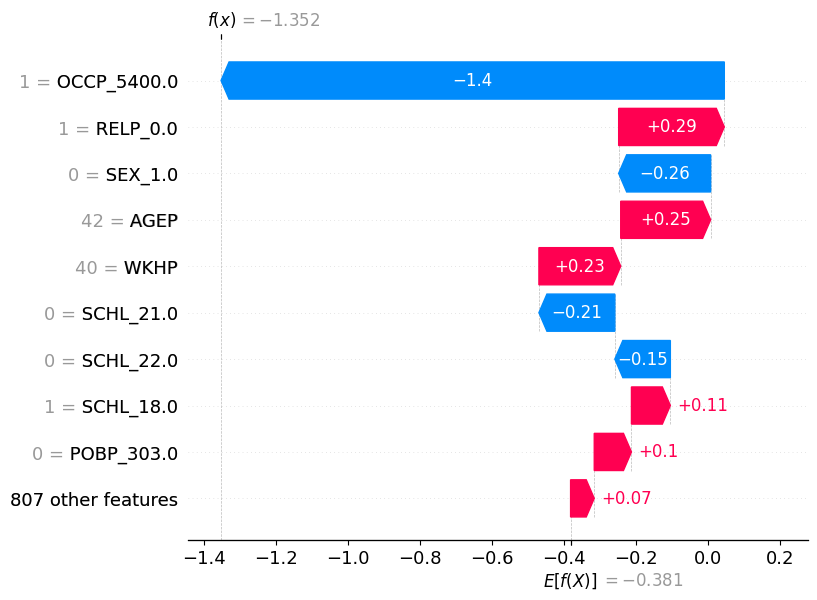

In [48]:
import shap

shap.initjs()

shap_explainer = shap.TreeExplainer(model)
shap_values = shap_explainer(features_test)

for i in samples_indices:
    shap.plots.waterfall(shap_values[i])

#### 3. Comparaison LIME et SHAP

[TODO]

#### 4 & 5. Analyse Summary plot de SHAP

##### 4. Approfondissement 1: Global

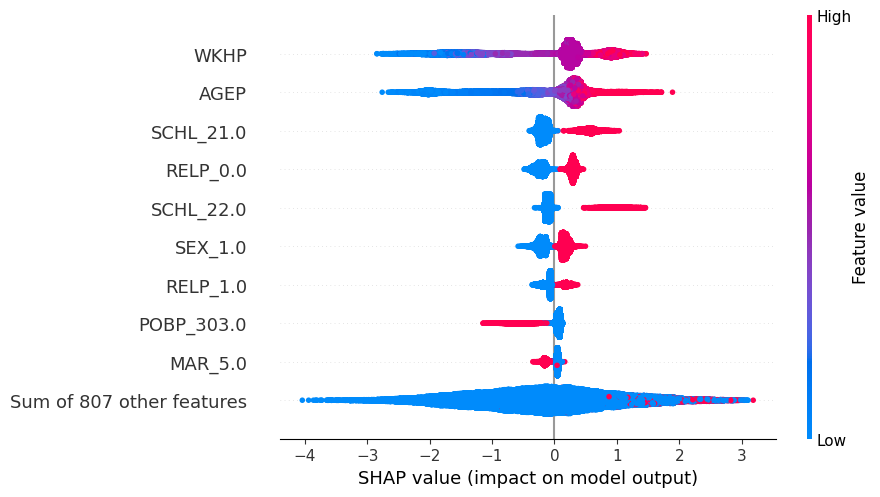

In [49]:
shap.plots.beeswarm(shap_values)

##### 5. Approfondissement 2: Par sous-groupes

TP


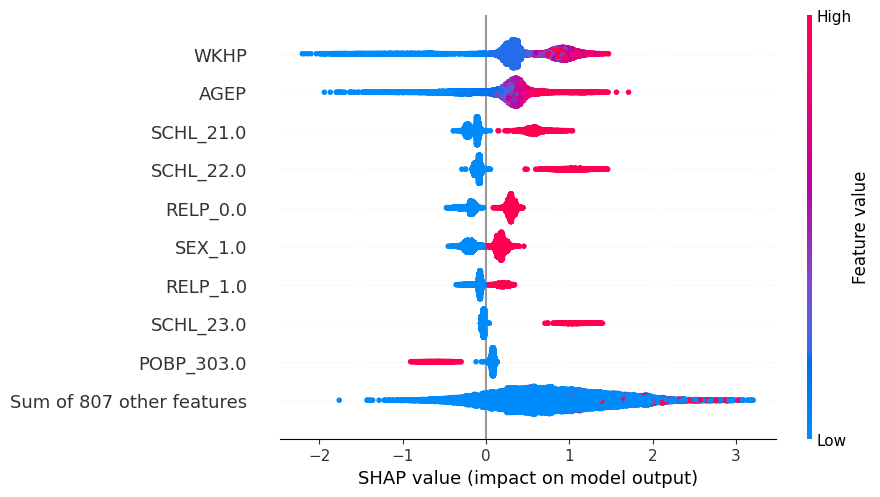

TN


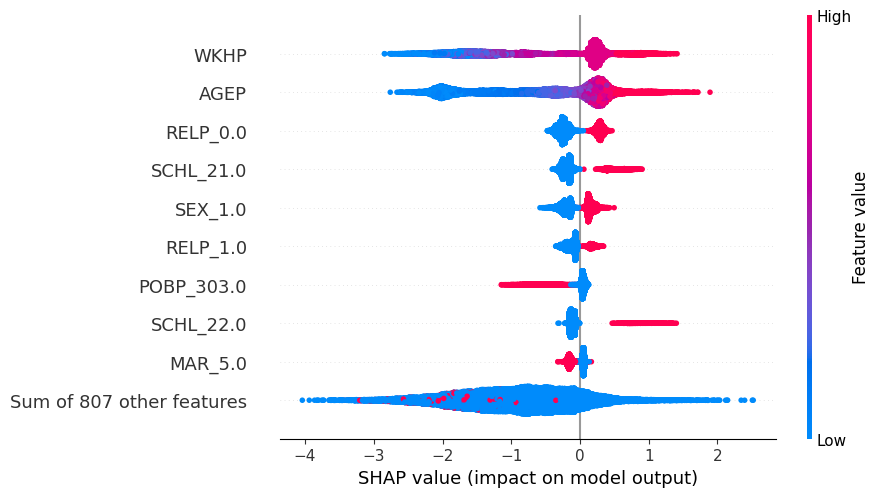

FP


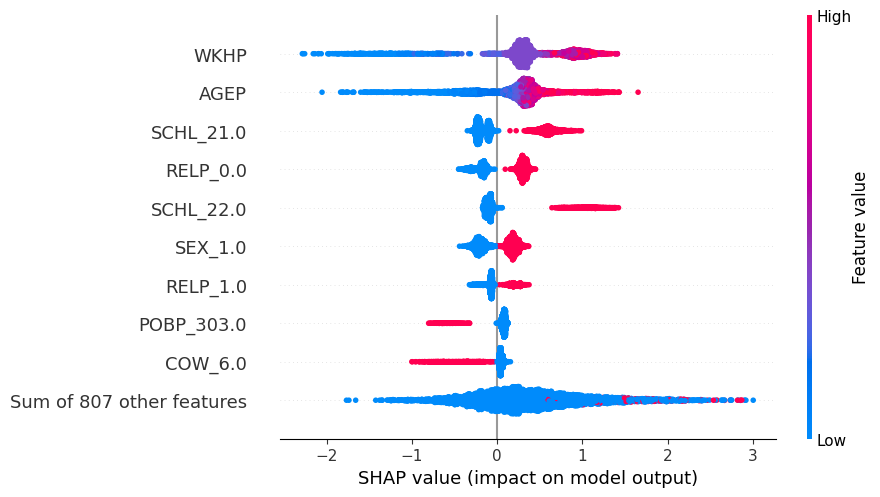

FN


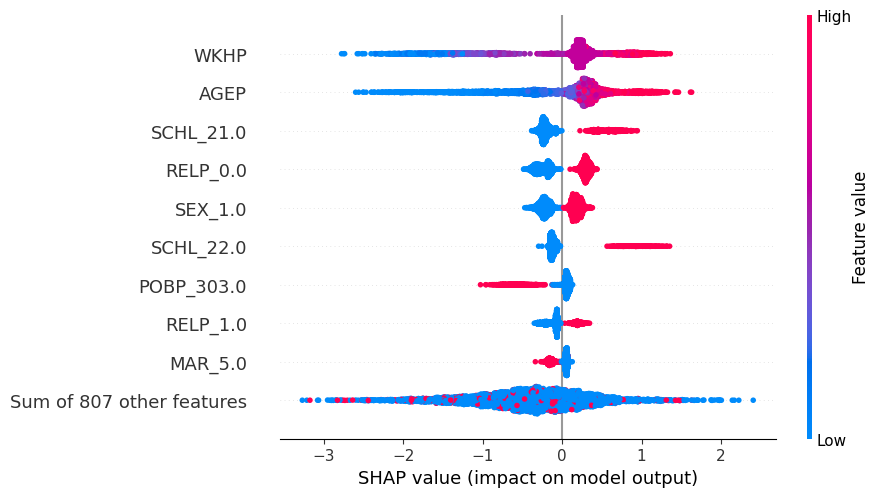

In [50]:
labels_pred = model.predict(features_test)

y_pred = labels_pred.squeeze()
y_test = labels_test.squeeze()

TP = features_test[(y_pred==1) & (y_test==1)]
TN = features_test[(y_pred==0) & (y_test==0)]
FP = features_test[(y_pred==1) & (y_test==0)]
FN = features_test[(y_pred==0) & (y_test==1)]

for name, group in [("TP",TP),("TN",TN),("FP",FP),("FN",FN)]:
    print(name)
    if len(group) > 0:
        shap_values_group = shap_explainer(group)
        shap.plots.beeswarm(shap_values_group)
    else:
        print("Aucun exemple dans le groupe")

### 3.3 Explication contrefactuelle